# **Text Analysis Using BioClinical ModernBERT**

## Project: Identifying and Analyzing Information Gaps in Women's Health Information

**Key:**
- 'Analyzing' dataset: Dataset of articles with female-specific topics
- 'Identifying' dataset: Dataset of articles with non-sex-specific diseases, which may also present differently between male and female patients

## Setup

In [ ]:
"""
For Running on Google Colab
"""
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install torch transformers scikit-learn pandas matplotlib seaborn

In [ ]:
import pandas as pd
import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure reproducibility
np.random.seed(42)
torch.manual_seed(42)

# NLTK Download
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Data Processing and Preparation

In [ ]:
def load_and_flatten_json(filepath):
    """Reads JSON and flattens the nested 'results' arrays into a standard DataFrame."""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    articles = []
    for row in data:
        if 'results' in row and isinstance(row['results'], list):
            for result in row['results']:
                result['query'] = row.get('query', '')
                articles.append(result)

    return pd.DataFrame(articles)

def clean_dataset(df, dataset_type="identifying"):
    df = df.drop_duplicates(subset=['full_article_text'])
    df = df[~df['full_article_text'].str.contains("access denied", case=False, na=False)]
    if dataset_type == "analyzing":
        df = df[~df['title'].str.contains(r'\bmale\b', case=False, na=False)]

    return df

# Load and clean
"""
Modifying filepaths for Google Colab run

analyzing_df = load_and_flatten_json('data/analyzing.json')
identifying_df = load_and_flatten_json('data/identifying.json')
"""
analyzing_df = load_and_flatten_json('/content/drive/MyDrive/honors-thesis/data/analyzing.json')
identifying_df = load_and_flatten_json('/content/drive/MyDrive/honors-thesis/data/identifying.json')

analyzing_df = clean_dataset(analyzing_df, "analyzing")
identifying_df = clean_dataset(identifying_df, "identifying")

"""
Downsampling 'Analyzing' Dataset
"""
# Downsample the 'analyzing' dataset by dropping 4 articles from each query group
analyzing_df = analyzing_df.groupby('query', group_keys=False).apply(
    lambda x: x.sample(n=max(0, len(x) - 4), random_state=42)
)

analyzing_df['Dataset'] = 'Female-Specific'
identifying_df['Dataset'] = 'Differently-Presenting'

# Combine for joint embedding space analysis
combined_df = pd.concat([analyzing_df, identifying_df], ignore_index=True)

# Drop rows with missing text
combined_df = combined_df.dropna(subset=['full_article_text'])

/tmp/ipykernel_3748/2243261133.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzing_df = analyzing_df.groupby('query', group_keys=False).apply(


### BioClinical ModernBERT Implementation

In [ ]:
# Load pre-trained BioClinical ModernBERT
model_name = "thomas-sounack/BioClinical-ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def get_mean_pooled_embeddings(texts, batch_size=8):
    """
    Generates mean-pooled document embeddings.
    Truncates to 8192 tokens per ModernBERT architectural limits.
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        # Handle both pandas Series and standard lists
        batch_texts = texts[i:i+batch_size].tolist() if hasattr(texts, 'tolist') else list(texts[i:i+batch_size])

        # Tokenize and pad
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # Extract last hidden state
        last_hidden_states = outputs.last_hidden_state

        # Mean pooling across the sequence length dimension, ignoring pad tokens
        attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden_states.size()).float()
        sum_embeddings = torch.sum(last_hidden_states * attention_mask, 1)
        sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask

        all_embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(all_embeddings)

# Generate embeddings for the entire corpus
print("Generating document embeddings...")
embeddings = get_mean_pooled_embeddings(combined_df['full_article_text'])
print(f"Generated embeddings shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating document embeddings...


W0424 18:25:32.223000 3748 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Generated embeddings shape: (810, 768)


**Preparing Phrase Arrays**

In [ ]:
"""
phrases_df = pd.read_excel('phrase_arrays.xlsx')
Modified filepaths for Google Colab run
"""
phrases_df = pd.read_excel('/content/drive/MyDrive/honors-thesis/phrase_arrays.xlsx')

# Map dictionary keys strictly to the new column headers
phrase_dict = {
    'mechanism_phrases': phrases_df['mechanism_phrases'].dropna().tolist(),
    'provider_phrases': phrases_df['provider_phrases'].dropna().tolist(),
    'endorsement_phrases': phrases_df['endorsement_phrases'].dropna().tolist(),
    'uncertainty_phrases': phrases_df['uncertainty_phrases'].dropna().tolist(),
    'female_associated': phrases_df['female_associated'].dropna().tolist() if 'female_associated' in phrases_df.columns else []
}

# Pre-compute embeddings for the updated phrase arrays
print("Embedding updated phrase arrays...")
embedded_arrays = {}
for category, phrases in phrase_dict.items():
    if phrases:
        embedded_arrays[category] = get_mean_pooled_embeddings(phrases)
    else:
        embedded_arrays[category] = np.array([])

Embedding updated phrase arrays...


In [ ]:
# 1. K-Means Clustering to identify dominant rhetorical frames
# k=3 is set as a baseline hypothesis
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

combined_df['Frame_Cluster'] = cluster_labels
combined_df['Frame_Cluster'] = combined_df['Frame_Cluster'].astype(str)

# 2. t-SNE for 2D visualization of the high-dimensional embedding space
print("Performing t-SNE reduction...")
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

combined_df['tsne_1'] = embeddings_2d[:, 0]
combined_df['tsne_2'] = embeddings_2d[:, 1]

Performing t-SNE reduction...


### Semantic Scoring

In [ ]:
def calculate_semantic_scores(article_text, embedded_arrays, threshold=0.80):
    """
    Splits an article into sentences, embeds them, and calculates the
    maximum cosine similarity against each phrase category.
    Returns the normalized count of sentences matching each category.
    """
    if not isinstance(article_text, str) or not article_text.strip():
        return {cat: 0.0 for cat in embedded_arrays.keys()}

    # Segment article into sentences
    sentences = nltk.sent_tokenize(article_text)
    if not sentences:
        return {cat: 0.0 for cat in embedded_arrays.keys()}

    # Embed all sentences in the article
    sentence_embeddings = get_mean_pooled_embeddings(sentences)

    scores = {}
    for category, phrase_matrix in embedded_arrays.items():
        if phrase_matrix.size == 0:
            scores[f'semantic_{category}_score'] = 0.0
            continue

        # Calculate similarity between all sentences and all phrases in this category
        # Shape: (num_sentences, num_phrases_in_category)
        sim_matrix = cosine_similarity(sentence_embeddings, phrase_matrix)

        # Find the maximum similarity score for each sentence
        max_sim_per_sentence = np.max(sim_matrix, axis=1)

        # Tally how many sentences exceed the semantic similarity threshold
        match_count = np.sum(max_sim_per_sentence >= threshold)

        # Normalize per 1,000 words for consistency with previous metrics
        word_count = len(nltk.word_tokenize(article_text))
        normalized_score = (match_count / max(word_count, 1)) * 1000

        scores[f'semantic_{category}_score'] = normalized_score

    return scores

def apply_semantic_pipeline(df):
    print(f"Processing dataset with {len(df)} articles...")

    # Apply the semantic scoring to each article
    semantic_results = df['full_article_text'].apply(
        lambda x: calculate_semantic_scores(str(x), embedded_arrays, threshold=0.82)
    )

    # Convert the dictionary results into DataFrame columns and concatenate
    semantic_df = pd.DataFrame(semantic_results.tolist(), index=df.index)
    return pd.concat([df, semantic_df], axis=1)

# Execute
analyzing_df = apply_semantic_pipeline(analyzing_df)
identifying_df = apply_semantic_pipeline(identifying_df)

Processing dataset with 415 articles...
Processing dataset with 395 articles...


## Visualizations

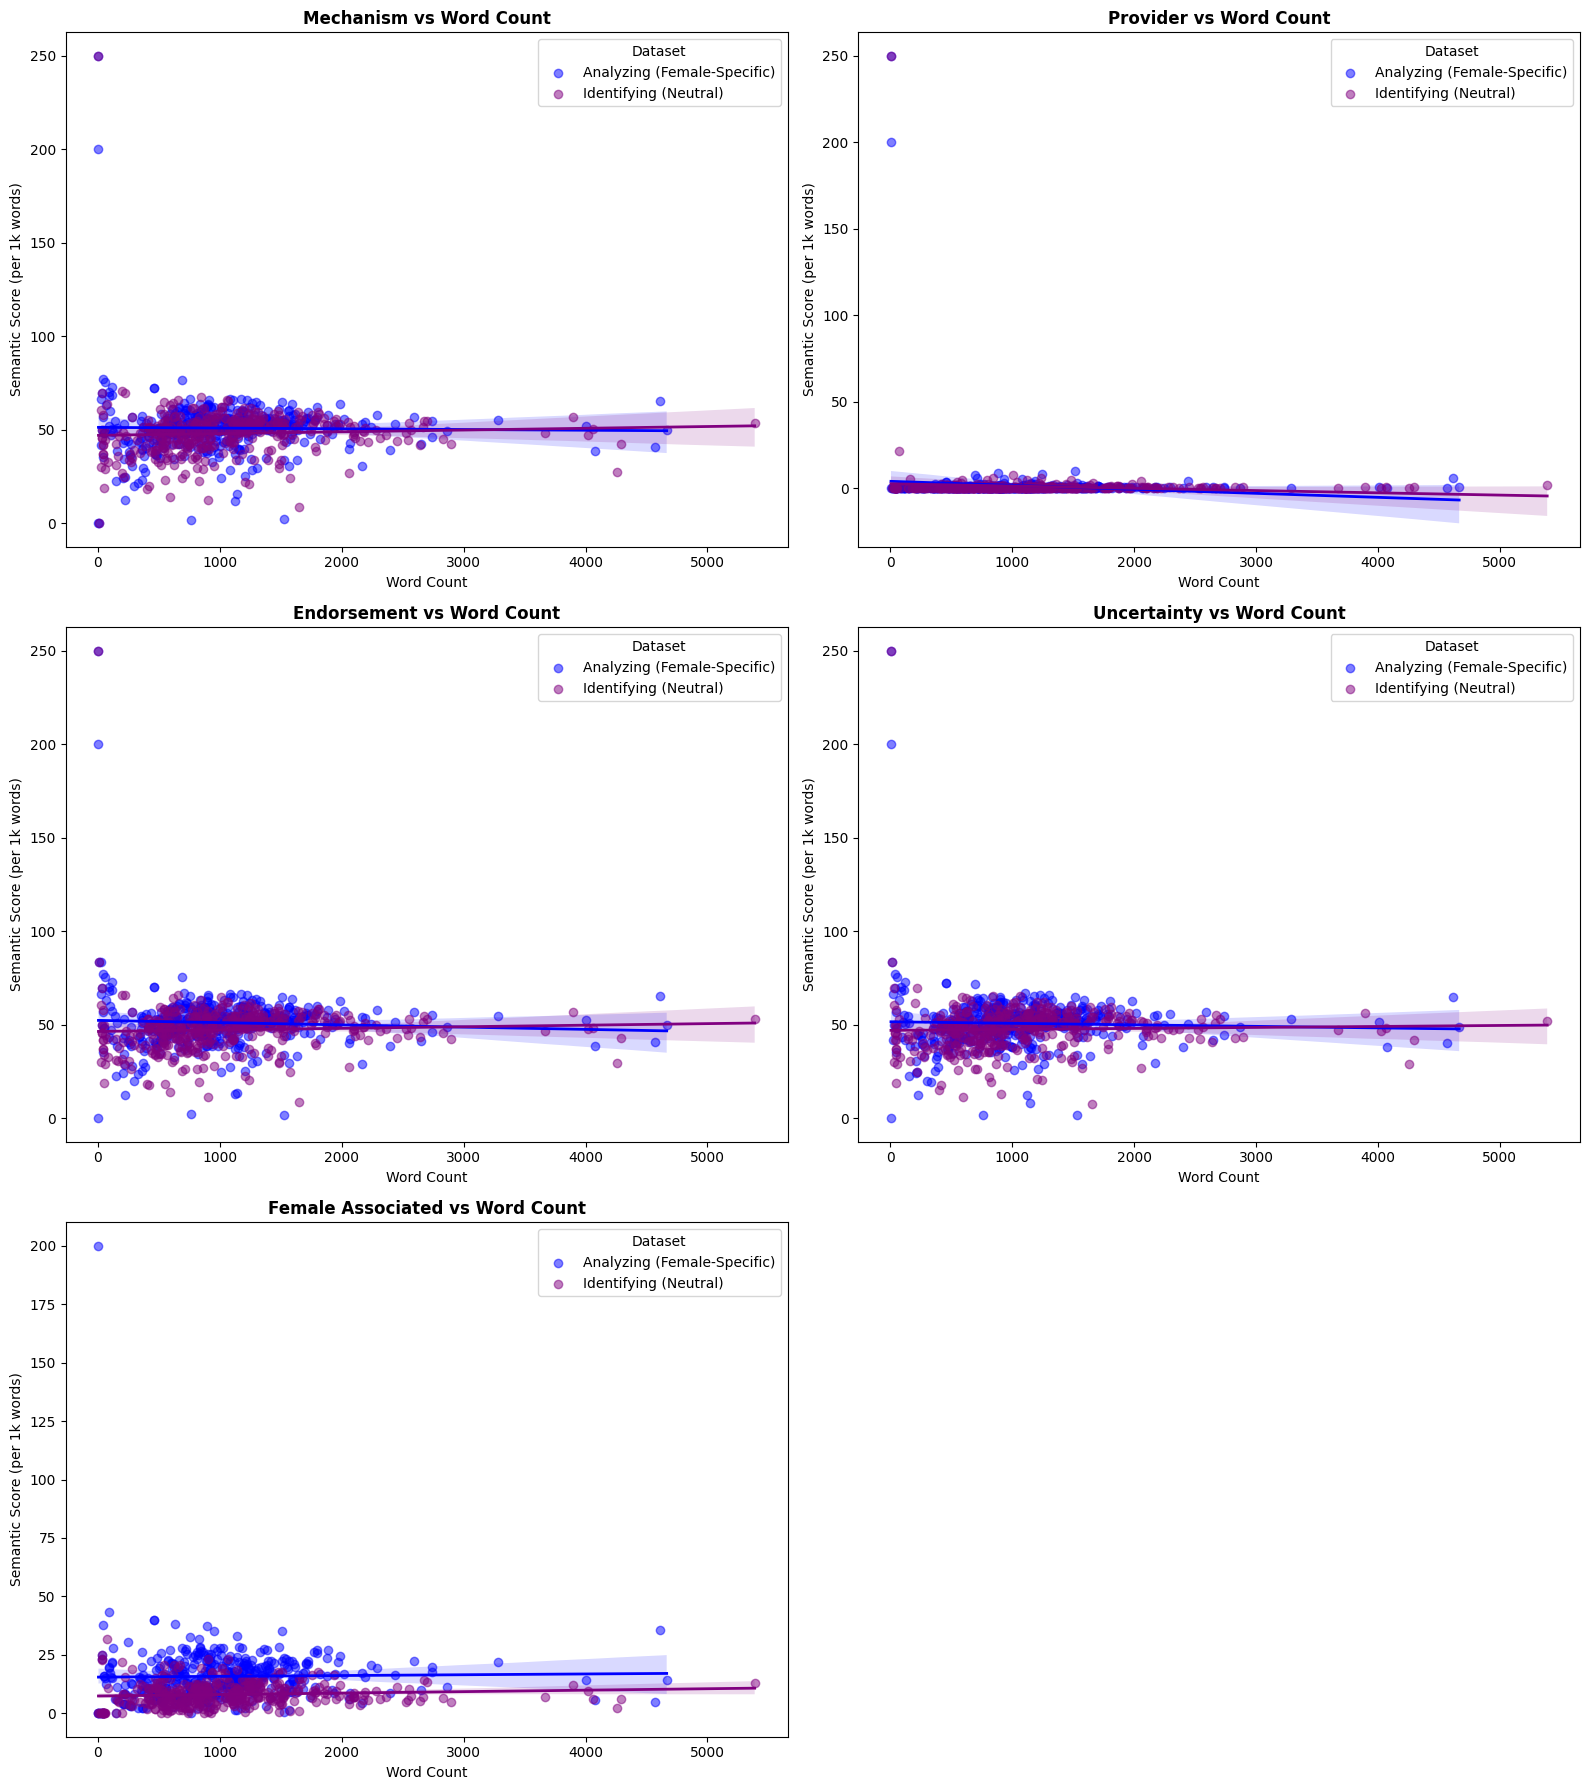

In [ ]:
"""
Scatter Plot with Regression Line
"""
# Define the shared semantic metrics
categories = [
    'semantic_mechanism_phrases_score',
    'semantic_provider_phrases_score',
    'semantic_endorsement_phrases_score',
    'semantic_uncertainty_phrases_score',
    'semantic_female_associated_score'
]

# Ensure combined_semantic_df exists and has 'word_count'
if 'combined_semantic_df' not in globals():
    analyzing_df['Dataset'] = 'Analyzing (Female-Specific)'
    identifying_df['Dataset'] = 'Identifying (Neutral)'
    combined_semantic_df = pd.concat([analyzing_df, identifying_df])

if 'word_count' not in combined_semantic_df.columns:
    combined_semantic_df['word_count'] = combined_semantic_df['full_article_text'].apply(
        lambda x: len(str(x).split()) if pd.notnull(x) else 0
    )

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(categories):
    for dataset in combined_semantic_df['Dataset'].unique():
        subset_df = combined_semantic_df[combined_semantic_df['Dataset'] == dataset]

        # Determine color based on dataset
        color = 'blue' if 'Analyzing' in dataset or 'Female' in dataset else 'purple'

        sns.regplot(
            data=subset_df,
            x='word_count',
            y=metric,
            ax=axes[i],
            scatter_kws={'alpha': 0.5},
            line_kws={'linewidth': 2},
            color=color,
            label=dataset
        )

    # Formatting
    clean_title = metric.replace("semantic_", "").replace("_phrases_score", "").replace("_score", "").replace("_", " ").title()
    axes[i].set_title(f'{clean_title} vs Word Count', fontweight='bold')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Semantic Score (per 1k words)')
    axes[i].legend(title='Dataset')

# Remove the empty 6th subplot since we only have 5 categories
if len(categories) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

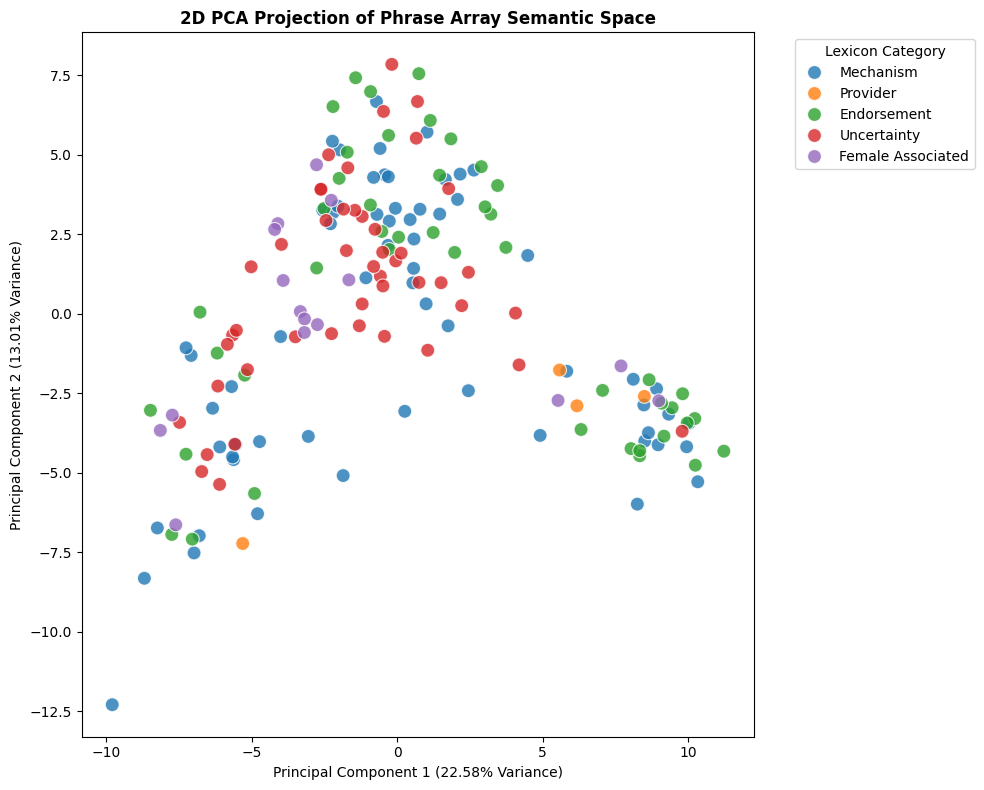

In [ ]:
"""
PCA
"""

# Aggregate all embedded phrases and their labels
all_phrase_embeddings = []
phrase_labels = []

for category, embedding_matrix in embedded_arrays.items():
    if embedding_matrix.size > 0:
        all_phrase_embeddings.append(embedding_matrix)
        # Clean label for legend
        label = category.replace('_phrases', '').replace('_', ' ').title()
        phrase_labels.extend([label] * embedding_matrix.shape[0])

# Stack and reduce dimensions
stacked_embeddings = np.vstack(all_phrase_embeddings)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(stacked_embeddings)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_embeddings[:, 0],
    y=reduced_embeddings[:, 1],
    hue=phrase_labels,
    palette='tab10',
    s=100,
    alpha=0.8
)

plt.title('2D PCA Projection of Phrase Array Semantic Space', fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(title='Lexicon Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

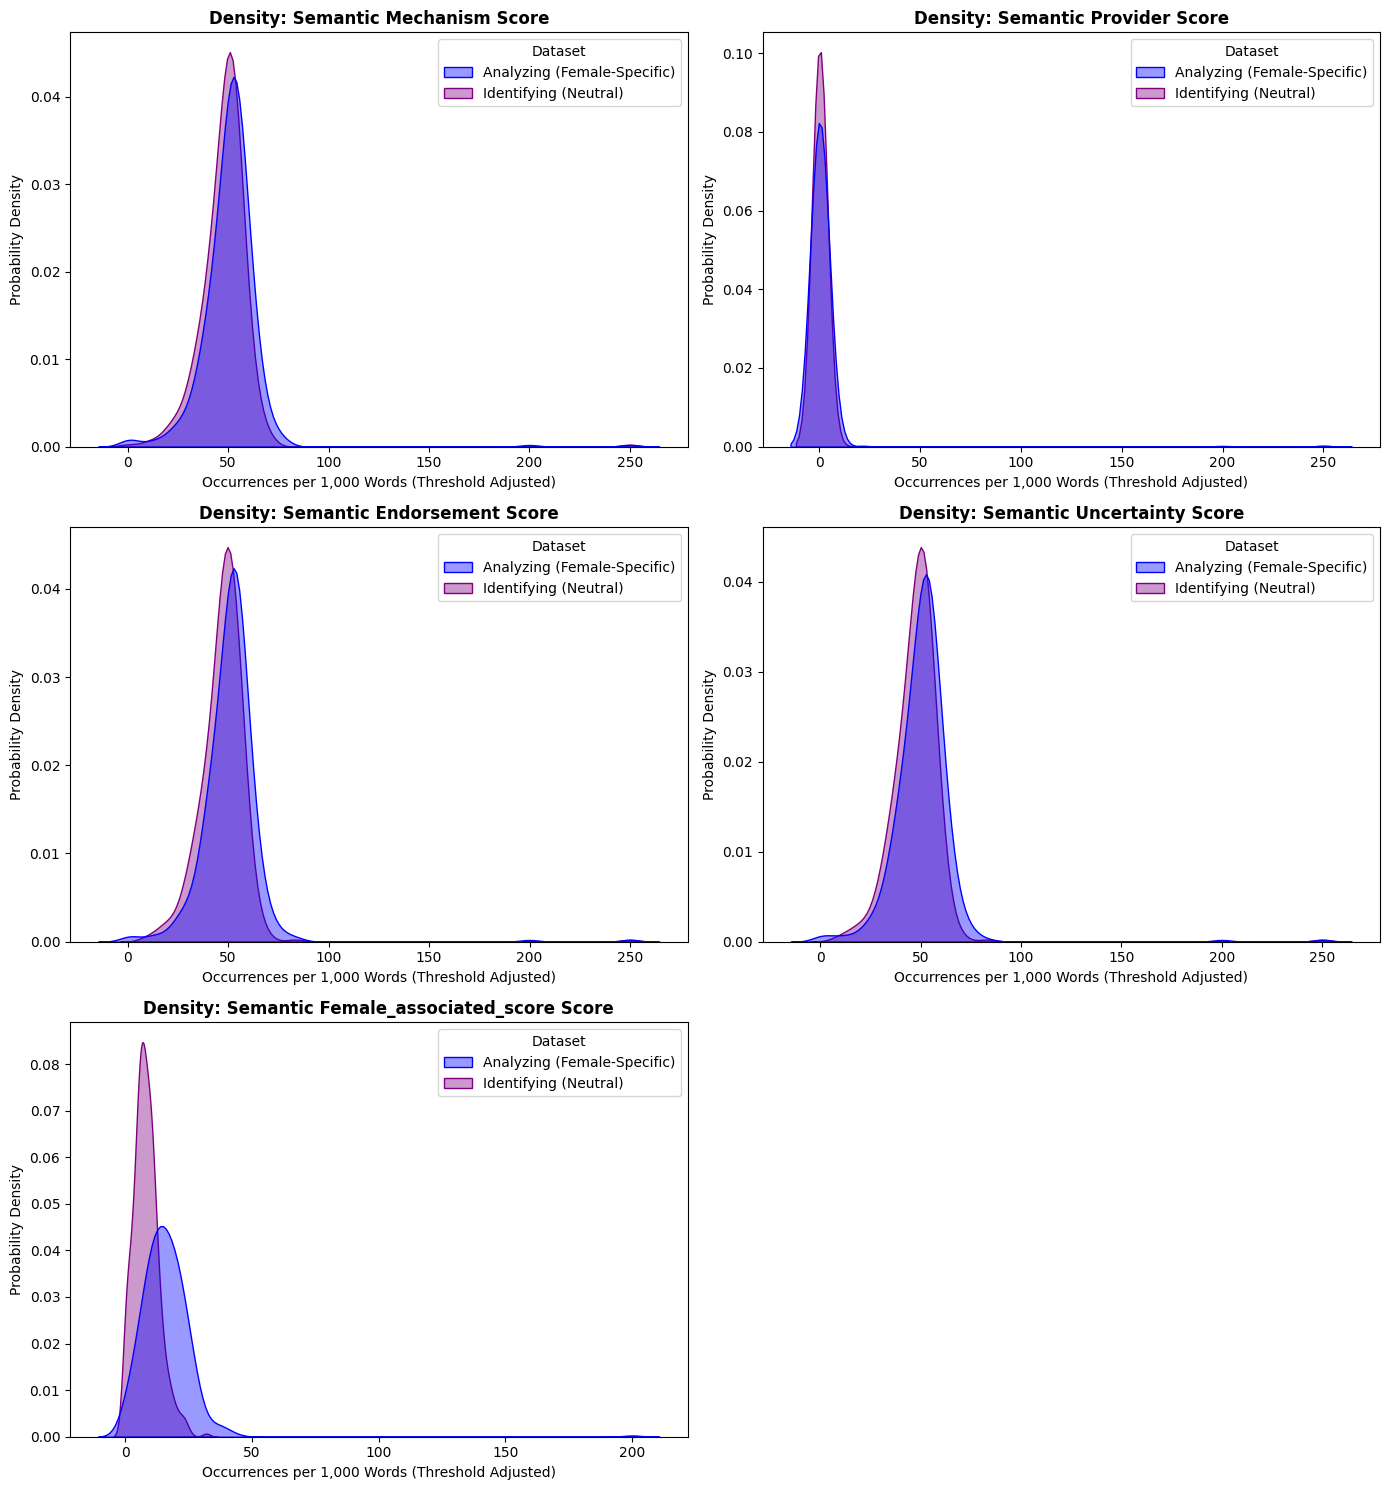

In [ ]:
"""
Semantic Density Distributions (KDE)
"""

# Prepare combined dataframe for unified plotting
analyzing_df['Dataset'] = 'Analyzing (Female-Specific)'
identifying_df['Dataset'] = 'Identifying (Neutral)'
combined_semantic_df = pd.concat([analyzing_df, identifying_df])

# Remove duplicate columns in case the pipeline was run multiple times
combined_semantic_df = combined_semantic_df.loc[:, ~combined_semantic_df.columns.duplicated()]

# 5 categories require at least 5 subplots, so a 3x2 grid is needed
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()

for i, category in enumerate(categories):
    sns.kdeplot(
        data=combined_semantic_df,
        x=category,
        hue='Dataset',
        fill=True,
        common_norm=False,
        palette=['blue', 'purple'],
        alpha=0.4,
        ax=axes[i]
    )

    clean_title = category.replace('semantic_', '').replace('_phrases_score', '').capitalize()
    axes[i].set_title(f'Density: Semantic {clean_title} Score', fontweight='bold')
    axes[i].set_xlabel('Occurrences per 1,000 Words (Threshold Adjusted)')
    axes[i].set_ylabel('Probability Density')

# Remove any extra empty subplots
if len(categories) < len(axes):
    for j in range(len(categories), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
target_metrics = [
    'word_count',
    'sentiment_score',
    'mechanism_phrases_score',
    'provider_phrases_score',
    'endorsement_phrases_score',
    'uncertainty_phrases_score',
    'female_associated_score',
    'semantic_mechanism_phrases_score',
    'semantic_provider_phrases_score',
    'semantic_endorsement_phrases_score',
    'semantic_uncertainty_phrases_score',
    'semantic_female_associated_score'
]

existing_metrics = [metric for metric in target_metrics if metric in identifying_df.columns]
identifying_means = identifying_df[existing_metrics].mean()
print(identifying_means)

semantic_mechanism_phrases_score      48.049013
semantic_provider_phrases_score        1.063408
semantic_endorsement_phrases_score    47.355152
semantic_uncertainty_phrases_score    47.587589
semantic_female_associated_score       8.087102
dtype: float64


In [ ]:
existing_metrics = [metric for metric in target_metrics if metric in analyzing_df.columns]
analyzing_means = analyzing_df[existing_metrics].mean()
print(analyzing_means)

semantic_mechanism_phrases_score      50.925103
semantic_provider_phrases_score        1.522675
semantic_endorsement_phrases_score    51.150836
semantic_uncertainty_phrases_score    50.793394
semantic_female_associated_score      15.836780
dtype: float64


### One-Way ANOVA Test

In [ ]:
import scipy.stats as stats

def perform_anova(df1, df2, metrics):
    results = []
    for metric in metrics:
        if metric in df1.columns and metric in df2.columns:
            f_stat, p_value = stats.f_oneway(df1[metric].dropna(), df2[metric].dropna())
            results.append({
                'Metric': metric,
                'F-Statistic': f_stat,
                'P-Value': p_value
            })
    return pd.DataFrame(results)

# Define the metrics calculated in the BioClinical ModernBERT pipeline
llm_metrics = [
    'semantic_mechanism_phrases_score',
    'semantic_provider_phrases_score',
    'semantic_endorsement_phrases_score',
    'semantic_uncertainty_phrases_score',
    'semantic_female_associated_score'
]

# Execute ANOVA
anova_results_llm = perform_anova(analyzing_df, identifying_df, llm_metrics)
print("BioClinical ModernBERT ANOVA Results:")
print(anova_results_llm)

BioClinical ModernBERT ANOVA Results:
                               Metric  F-Statistic       P-Value
0    semantic_mechanism_phrases_score     7.084787  7.928533e-03
1     semantic_provider_phrases_score     0.208931  6.477296e-01
2  semantic_endorsement_phrases_score    12.535733  4.220851e-04
3  semantic_uncertainty_phrases_score     8.865750  2.992536e-03
4    semantic_female_associated_score   141.575363  3.393591e-30
